In [ ]:
import os

os.environ['CUDA_VISIBLE_DEVICES'] = '3'    # GPU No.
from sampler.utils import *
#print(dir())
import importlib
import sampler.utils
importlib.reload(sampler.utils)
from trainer.utils import restore_checkpoint
import torch
import torch.nn as nn
import json
from collections import namedtuple
from tqdm import tqdm
from models import get_model, get_ema
from sampler import VESDE
import numpy as np
from einops import rearrange

data_name = 'era5'
version = 'v0'     
opt_path = './results/' + data_name + '_' + version + '/config.json'
with open(opt_path, 'r', encoding='utf-8') as f:
    opt = json.load(f)
    opt['num_channels'] = opt['num_components'] + opt['num_conditions']
OPT_class = namedtuple('OPT_class', opt.keys())
opt = OPT_class(**opt)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load pretrained model

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
net = get_model(opt)
#net = nn.DataParallel(net)
net.to(device)
ema = get_ema(net.parameters(), decay=opt.ema_rate)
optimizer = torch.optim.Adam(net.parameters(), lr=opt.lr, betas=(0.9, 0.999), eps=1e-8, weight_decay=0)
state = dict(optimizer=optimizer, model=net, ema=ema, epoch=0, iteration=0, loss_train=[])

ckpt_path = opt.results_path + '/checkpoint.pth'

state = restore_checkpoint(ckpt_path, state, device)
net = state['model']
ema = state['ema']
ema.copy_to(net.parameters())
print('Model loaded from epoch', state['epoch'])

Model loaded from epoch 98


# Load test data

In [ ]:
import numpy as np

file_path = '/results/era5_v0/scalars_era5.npy'

try:
    scalars = np.load(file_path)
    var_names = ['u', 'v', 'T', 'P']
    for i, name in enumerate(var_names):
        mean_val = scalars[i, 0]
        std_val = scalars[i, 1]
        print(f"{name}: Mean = {mean_val:.4f}, Std = {std_val:.4f}")

except Exception as e:
    print(f"fail: {e}")

--- 数组内容 ---
[[ 9.61756921e-03  3.41567202e+00]
 [-5.31167360e-02  2.96506737e+00]
 [ 2.89967733e+02  1.50937727e+01]
 [ 9.47438056e+04  1.05833972e+04]]

--- 维度信息 ---
Shape: (4, 2)

--- 解析数据 (假设结构为 Mean 和 Std) ---
变量 u: Mean = 0.0096, Std = 3.4157
变量 v: Mean = -0.0531, Std = 2.9651
变量 T: Mean = 289.9677, Std = 15.0938
变量 P: Mean = 94743.8056, Std = 10583.3972


In [59]:
data_test_path = "./data/era5/era5_test.npy"
scalar_path = opt.results_path + '/scalars_era5.npy'
data_raw = np.load(data_test_path)
_, z = np.meshgrid(np.linspace(0, 2 * np.pi, opt.image_size, endpoint=False),
                    np.linspace(0, 2 * np.pi, opt.image_size, endpoint=False), indexing='ij')
x_test = data_raw.transpose(0, 1, 4, 2, 3)
print(x_test.shape)

(1, 273, 4, 64, 64)


# Load test data

In [60]:
m           =   2                                       # overlap
T           =   opt.num_frames                          # number of frames within a single sample
T_prime     =   100                                      # length of frames you want to generate
B           =   int(np.ceil((T_prime-m) / (T - m)))     # number of samples for parallel generation
T_prime     =   B * (T - m) + m                         # the total length might be a little longer than the given length
n_samples   =   1                                       # batch size

samples = []
seed_samples = 1
rnd = np.random.RandomState(seed_samples)

'''experimental samples'''
t_start = 0
samples = x_test[:, t_start:t_start+T_prime]
print(samples.shape)

(1, 106, 4, 64, 64)


# Reconstruction

In [ ]:
outer_loop = 50    # predictor steps
denoising_steps = 50

seed_sample = 123
#seed_sample = 1

obs_type = 'random'     # 'random', 'regular', 'forecast'
scale = 0.95            # scale is: mask ratio (float between 0 and 1, e.g., 0.98) for 'random', down-sampling rate (int, e.g., 8) for 'regular', number of initial frames (int, e.g., 2) for 'forecast'

# hyperparameters for generating stage
alpha_case = 0.3
beta = 0.4
gamma = 0.5

sde = VESDE(opt, sigma_min=opt.beta_min, sigma_max=opt.beta_max, N=outer_loop)
sde1 = VESDE(opt, sigma_min=opt.beta_min, sigma_max=opt.beta_max, N=denoising_steps)
net.eval()
reap_fn = lambda x, num: torch.stack([x for _ in range(num)])

setup_seed(seed_sample)
with torch.no_grad():
    '''
    if obs_type.lower() == 'random':
        T_prime_y = T_prime                      # sequence that is dependent on observation
        mask = np.zeros([opt.num_components+opt.num_conditions, opt.image_size, opt.image_size])
        mask[:opt.num_components] = mask_gen([1, opt.image_size, opt.image_size], scale, seed=seed_samples)
        mask_torch = torch.from_numpy(mask).to(device)
        transform_gen = transform = lambda x:x[:, :T_prime_y]*mask[np.newaxis, np.newaxis] if isinstance(x, np.ndarray) else x[:, :T_prime_y]*mask_torch[None, None].to(x.device)   # only the observable frames are given
        sparsity = scale            # calculate sparsity of each task
    '''
    if obs_type.lower() == 'random':
        T_prime_y = T_prime                      # sequence that is dependent on observation
        mask = np.zeros([opt.num_components+opt.num_conditions, opt.image_size, opt.image_size])
        spatial_mask = mask_gen([1, opt.image_size, opt.image_size], scale, seed=seed_samples)
        mask[:opt.num_components] = mask_gen([1, opt.image_size, opt.image_size], scale, seed=seed_samples)
        mask_torch = torch.from_numpy(mask).to(device)
        transform_gen = transform = lambda x:x[:, :T_prime_y]*mask[np.newaxis, np.newaxis] if isinstance(x, np.ndarray) else x[:, :T_prime_y]*mask_torch[None, None].to(x.device)   # only the observable frames are given
        sparsity = scale            # calculate sparsity of each task

    elif obs_type.lower() == 'regular':
        '''regularly located observation'''
        T_prime_y = T_prime
        transform_gen = transform = lambda x:x[:, :T_prime_y, :, ::scale, ::scale]     # only the observable frames are given
        sparsity = 1-1/scale**2     # calculate sparsity of each task
    elif obs_type.lower() == 'forecast':
        T_prime_y = 0
        transform_gen = transform = lambda x:x[:, :scale]
        sparsity = 1-scale/T        # calculate sparsity of each task

    alpha = alpha_case/np.sqrt(1-sparsity)
    
    samples_scale = samples.copy()
    #samples_scale[:, :, :opt.num_components] = scalar(samples_scale[:, :, :opt.num_components])
    y = transform_gen(samples_scale)
    #y = y1[:, :, 0:2, :, :]
    print(y.shape)

    latent_mask = torch.ones([T, 1, 1, 1]).float().to(device)
    obs_mask = torch.zeros([T, 1, 1, 1]).float().to(device)
    frame_indices = torch.arange(T).to(device)
    net_fn = lambda x, t: net(x, x0=x, timesteps=t, latent_mask=reap_fn(latent_mask, len(x)), obs_mask=reap_fn(obs_mask, len(x)), frame_indices=reap_fn(frame_indices, len(x)))[0]

    x_inpainted = s3gm_sample_2d(opt, net_fn, sde, y,
                              transform_gen,
                              alpha=0.2/np.sqrt(1-sparsity), beta=beta, gamma=gamma,
                              T_prime_y=T_prime_y, T_prime=T_prime, overlap=m,
                              corrector=NoneCorrector,
                              snr=0.128, device=device, dtype='float', eps=1e-12,
                              probability_flow=False, continuous=True)
    setup_seed(seed_sample)
    
    x_inpainted1 = MRSM_sample_2d_ISS_ERA5(opt, net_fn, sde1, y,
                                         transform_gen,
                                         alpha=0.3/np.sqrt(1-sparsity), beta=beta, gamma=gamma,
                                         T_prime_y=T_prime_y, T_prime=T_prime, overlap=m,
                                         corrector=NoneCorrector,
                                         n_steps=0,
                                         eta=0, 
                                         #reg_coef_pa = 100*T_prime, 
                                         reg_coef_pa = 0,
                                         reg_coef_ar = 0,
                                         denoising_steps=denoising_steps,
                                         snr=0.128, device=device, dtype='float', eps=1e-12,
                                         probability_flow=False, continuous=True)

x_pred = x_inpainted
x_pred1 = x_inpainted1
print(x_pred.shape)

errors = cal_rmse(samples[0], x_pred[0], normalize=True)
#errors = cal_rmse(samples[0, :, 0:2, :], x_pred[0, :, 0:2, :], normalize=True)
mean_error = np.mean(errors)
print(f'mean_error: {mean_error}')

errors1 = cal_rmse(samples[0], x_pred1[0], normalize=True)
#errors1 = cal_rmse(samples[0, :, 0:2, :], x_pred1[0, :, 0:2, :], normalize=True)
mean_error1 = np.mean(errors1)
print(f'mean_error1: {mean_error1}')

num_T = x_pred.shape[1]
print(f'Number of generated snapshots: {num_T}')
torch.cuda.empty_cache()

(1, 106, 4, 64, 64)


loss total: 1.19604e+03 | loss obs.: 9.65081e+01 | loss consis.: 1.09953e+03: 100%|█████| 50/50 [00:05<00:00,  8.34it/s]
SDE | loss total: 5.10577e+02 | loss obs.: 1.14009e+02 | loss consis.: 3.96567e+02 | reg_loss.: 0.00000e+00: 100%|█| 50/


(1, 106, 4, 64, 64)
mean_error: 0.32131427669288504
mean_error1: 0.2694188218803556
Number of generated snapshots: 106


# Visualization

Plotting time steps: [20, 40, 60, 80, 100]
图像已保存至: /media/zzy/raid5/results_ERA5/ERA5_4Split_Layout.eps


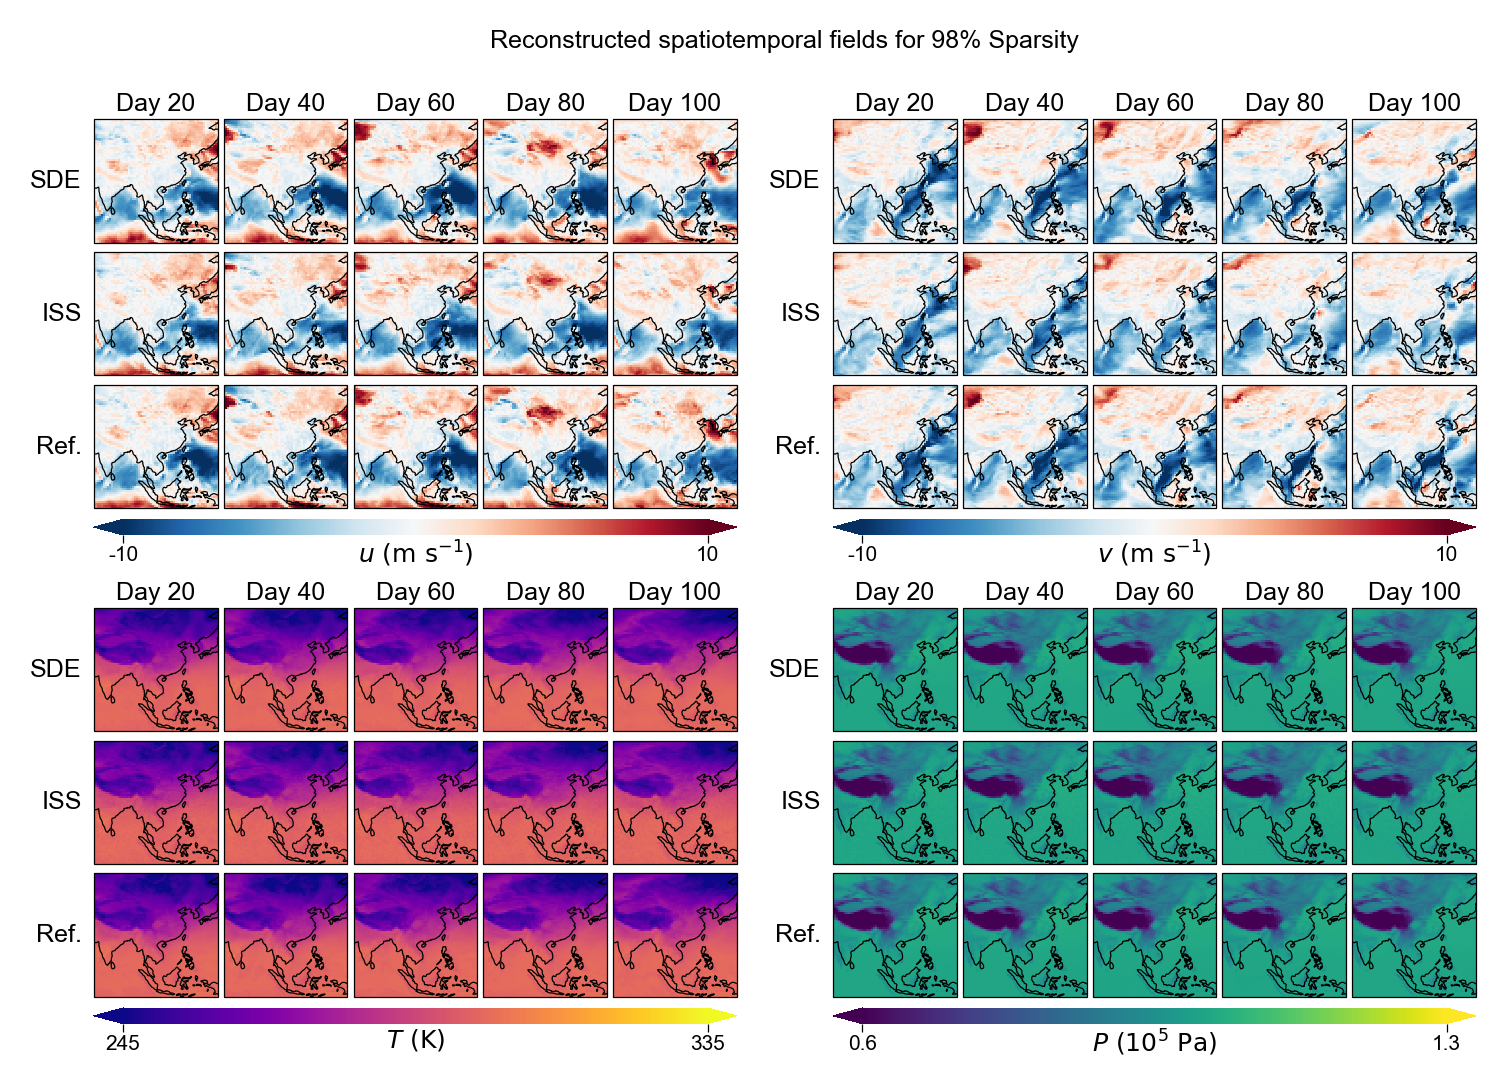

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature


SUBPLOT_WIDTH_CM = 6.0 
TOTAL_WIDTH_CM = SUBPLOT_WIDTH_CM * 2 + 1.0 
TOTAL_WIDTH_INCH = TOTAL_WIDTH_CM / 2.54
DPI_FOR_PUBLICATION = 300 


mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
mpl.rcParams['font.weight'] = 'normal'

UNIFORM_FONT_SIZE = 6
TICK_FONT_SIZE = 5

mpl.rcParams['font.size'] = UNIFORM_FONT_SIZE
mpl.rcParams['axes.labelsize'] = UNIFORM_FONT_SIZE
mpl.rcParams['xtick.labelsize'] = TICK_FONT_SIZE
mpl.rcParams['ytick.labelsize'] = TICK_FONT_SIZE


mpl.rcParams['axes.linewidth'] = 0.3      
mpl.rcParams['xtick.major.width'] = 0.3     
mpl.rcParams['ytick.major.width'] = 0.3


REGION = [70, 140, -10, 60] 


NORM_STATS = {
    'u': {'mean': 0.0096,     'std': 3.4157},
    'v': {'mean': -0.0531,     'std': 2.9651},
    'T': {'mean': 289.9677,   'std': 15.0938},
    'P': {'mean': 94743.8056, 'std': 10583.3972}
}

def plot_era5_split_layout(x_pred, x_pred1, samples, time_steps_all, 
                           save_path='ERA5_Reconstructed_95Sparsity.eps'):

    time_steps_to_plot = time_steps_all[1:] # e.g. [20, 40, 60, 80, 100]
    print(f"Plotting time steps: {time_steps_to_plot}")

    variables = [
        {'name': 'u', 'idx': 0, 'unit': 'm s^{-1}', 'range': [-10, 10], 'cmap': 'RdBu_r', 'label': r'$u\ (\mathrm{m\ s^{-1}})$'},
        {'name': 'v', 'idx': 1, 'unit': 'm s^{-1}', 'range': [-10, 10], 'cmap': 'RdBu_r', 'label': r'$v\ (\mathrm{m\ s^{-1}})$'},
        {'name': 'T', 'idx': 2, 'unit': 'K',        'range': [245, 335], 'cmap': 'plasma', 'label': r'$T\ (\mathrm{K})$'}, 
        {'name': 'P', 'idx': 3, 'unit': 'Pa',       'range': [60000, 130000], 'cmap': 'viridis', 'label': r'$P\ (10^5\ \mathrm{Pa})$'} 
    ]
    
    methods = ['SDE', 'ISS', 'Ref.']
    n_methods = len(methods)
    n_cols = len(time_steps_to_plot)

    map_ratio = (REGION[3] - REGION[2]) / (REGION[1] - REGION[0]) 
    
    figsize_height = TOTAL_WIDTH_INCH * 0.7 

    fig = plt.figure(figsize=(TOTAL_WIDTH_INCH, figsize_height), dpi=DPI_FOR_PUBLICATION)
    
    outer_gs = gridspec.GridSpec(2, 2, figure=fig, 
                                 wspace=0.15, hspace=0.15,
                                 left=0.05, right=0.95, top=0.90, bottom=0.05)

    
    if samples.ndim == 5:
        H_grid, W_grid = samples.shape[-2], samples.shape[-1]
    else:
        H_grid, W_grid = samples.shape[-2], samples.shape[-1]
    
    lon = np.linspace(REGION[0], REGION[1], W_grid)
    lat = np.linspace(REGION[3], REGION[2], H_grid) 
    lon_grid, lat_grid = np.meshgrid(lon, lat)

    for i, var_dict in enumerate(variables):
        outer_ax = outer_gs[i]
        
        inner_gs = gridspec.GridSpecFromSubplotSpec(n_methods + 1, n_cols, 
                                                    subplot_spec=outer_ax,
                                                    wspace=0.05, hspace=0.02,
                                                    height_ratios=[1, 1, 1, 0.2]) 

        var_name = var_dict['name']
        ch = var_dict['idx']
        vmin, vmax = var_dict['range']
        cmap = var_dict['cmap']
        
        stats = NORM_STATS.get(var_name, {'mean': 0, 'std': 1})
        mean_val = stats['mean']
        std_val = stats['std']

        plot_handle = None 
        for m_i, method in enumerate(methods):
            if method == 'SDE':   raw_data = x_pred[0, :, ch]
            elif method == 'ISS': raw_data = x_pred1[0, :, ch]
            elif method == 'Ref.': raw_data = samples[0, :, ch]
            
            if hasattr(raw_data, 'cpu'): raw_data = raw_data.cpu().numpy()

            for t_j, t_val in enumerate(time_steps_to_plot):
                try:
                    original_idx = time_steps_all.index(t_val)
                    norm_field = raw_data[original_idx]
                except (ValueError, IndexError):
                    continue

                phys_field = norm_field * std_val + mean_val

                ax = fig.add_subplot(inner_gs[m_i, t_j], projection=ccrs.PlateCarree())
                ax.set_extent(REGION, crs=ccrs.PlateCarree())
                ax.add_feature(cfeature.COASTLINE, linewidth=0.3, edgecolor='black', zorder=10)
                ax.spines['geo'].set_linewidth(0.3)
                
                im = ax.pcolormesh(lon_grid, lat_grid, phys_field, 
                                   transform=ccrs.PlateCarree(),
                                   cmap=cmap, vmin=vmin, vmax=vmax, 
                                   rasterized=True, zorder=1)
                
                if plot_handle is None: plot_handle = im

                gl = ax.gridlines(draw_labels=False, linewidth=0)
                
                if t_j == 0:
                    ax.text(-0.1, 0.5, method, transform=ax.transAxes, 
                            fontsize=UNIFORM_FONT_SIZE, va='center', ha='right', weight='normal')
                
                if m_i == 0:
                    ax.set_title(f"Day {t_val}", fontsize=UNIFORM_FONT_SIZE, pad=2)

        cax = fig.add_subplot(inner_gs[n_methods, :])
        
        pos = cax.get_position()
        new_height = pos.height * 0.4 
        new_y = pos.y0 + pos.height * 0.2 
        cax.set_position([pos.x0, new_y, pos.width, new_height*1.5])

        cb = fig.colorbar(plot_handle, cax=cax, orientation='horizontal', extend='both')
        
        ticks = [vmin, vmax]
        if var_name == 'P':
             ticks = [vmin, vmax] # 或者 [vmin, (vmin+vmax)/2, vmax]
        
        cb.set_ticks(ticks)
        cb.ax.tick_params(labelsize=TICK_FONT_SIZE, length=2, width=0.3, direction='out',pad=0.5)
        cb.outline.set_visible(False)
        
        if var_name == 'P':
            cb.ax.set_xticklabels([f'{x/100000:.1f}' for x in ticks])
        else:
            cb.ax.set_xticklabels([f'{x:.0f}' for x in ticks])

        label_text = var_dict['label']
        cax.text(0.5, -0.2, label_text, transform=cax.transAxes, 
                 ha='center', va='top', fontsize=UNIFORM_FONT_SIZE)

    fig.suptitle('Reconstructed spatiotemporal fields for 98% Sparsity', 
                 fontsize=UNIFORM_FONT_SIZE, y=0.98)
    plt.show()

all_time_steps = [1, 20, 40, 60, 80, 100]
plot_era5_split_layout(x_pred, x_pred1, samples, all_time_steps, save_path=save_file)

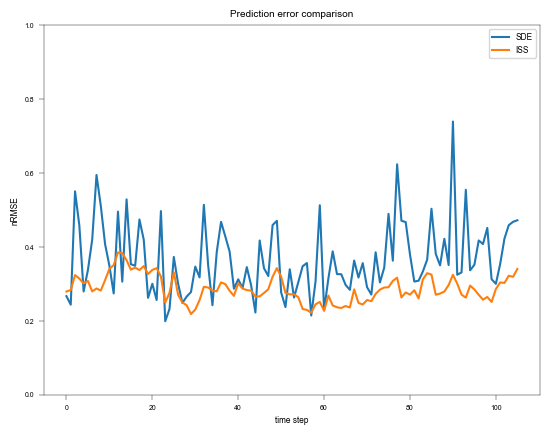

In [55]:
errors = cal_rmse(samples[0], x_pred[0], normalize=True)
errors1 = cal_rmse(samples[0], x_pred1[0], normalize=True)

'''
errors = cal_rmse(samples[0, :, 0:2, :], x_pred[0, :, 0:2, :], normalize=True)
errors1 = cal_rmse(samples[0, :, 0:2, :], x_pred1[0, :, 0:2, :], normalize=True)
errors = cal_rmse(samples[0, :, 3, :], x_pred[0, :, 3, :], normalize=True)
errors1 = cal_rmse(samples[0, :, 3, :], x_pred1[0, :, 3, :], normalize=True)
'''

plt.plot(errors, label='SDE')  
plt.plot(errors1, label='ISS') 

plt.xlabel('time step')
plt.ylabel('nRMSE')
plt.title('Prediction error comparison')
plt.legend()
plt.ylim(0, 1)
#plt.xlim(230, 250)
plt.show()